# 1. Median Income Map

In [32]:
import pandas as pd
import shapely
import numpy as np
import fiona
import geopandas as gpd
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
import os
os.listdir()

['ACSST1Y2024.S1903-Data.csv',
 'ACSST5Y2024.S0802-Data.csv',
 'ACSST5Y2024.S1701-Data.csv',
 'ACSST5Y2024.S1903-Data.csv',
 'ACSST5Y2024.S2201-Data.csv',
 'bexar_heat_maps.ipynb',
 'bexar_metropolitan.csv',
 'bexar_poverty.csv',
 'Bexar_snap_map.png',
 'cleaned_bexar_data.ipynb',
 'cleaned_bexar_snap_data.csv',
 'income_data.csv',
 'mapping_bexar_snap.ipynb',
 'snap_data.csv',
 'snap_retailer_location_data.csv',
 'tl_2024_48_tract.cpg',
 'tl_2024_48_tract.dbf',
 'tl_2024_48_tract.prj',
 'tl_2024_48_tract.shp',
 'tl_2024_48_tract.shp.ea.iso.xml',
 'tl_2024_48_tract.shp.iso.xml',
 'tl_2024_48_tract.shx',
 'vehicle_data.csv']

In [33]:
df = pd.read_csv('income_data.csv')
df

,GEO_ID,NAME,S1903_C01_001E,S1903_C01_001M,S1903_C01_002E,S1903_C01_002M,S1903_C01_003E,S1903_C01_003M,S1903_C01_004E,S1903_C01_004M,...,S1903_C03_036E,S1903_C03_036M,S1903_C03_037E,S1903_C03_037M,S1903_C03_038E,S1903_C03_038M,S1903_C03_039E,S1903_C03_039M,S1903_C03_040E,S1903_C03_040M
0,Geography,Geographic Area Name,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...
1,1400000US48029110100,Census Tract 1101; Bexar County; Texas,2659,341,1515,396,134,153,40,54,...,57276,9439,-,**,40921,20086,37405,15921,-,**
2,1400000US48029110300,Census Tract 1103; Bexar County; Texas,1139,284,569,233,114,106,12,18,...,-,**,117896,91739,-,**,-,**,-,**
3,1400000US48029110500,Census Tract 1105; Bexar County; Texas,1115,136,395,125,116,82,25,42,...,24250,16762,83494,6778,34826,12231,-,**,-,**
4,1400000US48029110600,Census Tract 1106; Bexar County; Texas,1482,249,255,101,101,102,42,43,...,16154,4870,-,**,21448,3831,19678,3195,24012,5966
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,1400000US48029980002,Census Tract 9800.02; Bexar County; Texas,0,15,0,15,0,15,0,15,...,-,**,-,**,-,**,-,**,-,**
372,1400000US48029980003,Census Tract 9800.03; Bexar County; Texas,260,52,183,49,30,26,0,15,...,53158,14925,-,**,53726,252,-,**,53672,1072
373,1400000US48029980004,Census Tract 9800.04; Bexar County; Texas,0,15,0,15,0,15,0,15,...,-,**,-,**,-,**,-,**,-,**
374,1400000US48029980005,Census Tract 9800.05; Bexar County; Texas,19,8,10,10,0,15,4,7,...,-,**,-,**,-,**,-,**,-,**


In [34]:
gdf = gpd.read_file("tl_2024_48_tract.shp")

In [35]:
bexar = gdf[gdf["COUNTYFP"] == "029"]

In [36]:
merged = bexar.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [37]:
merged["S1903_C03_001E"] = pd.to_numeric(
    merged["S1903_C03_001E"],
    errors="coerce"
)

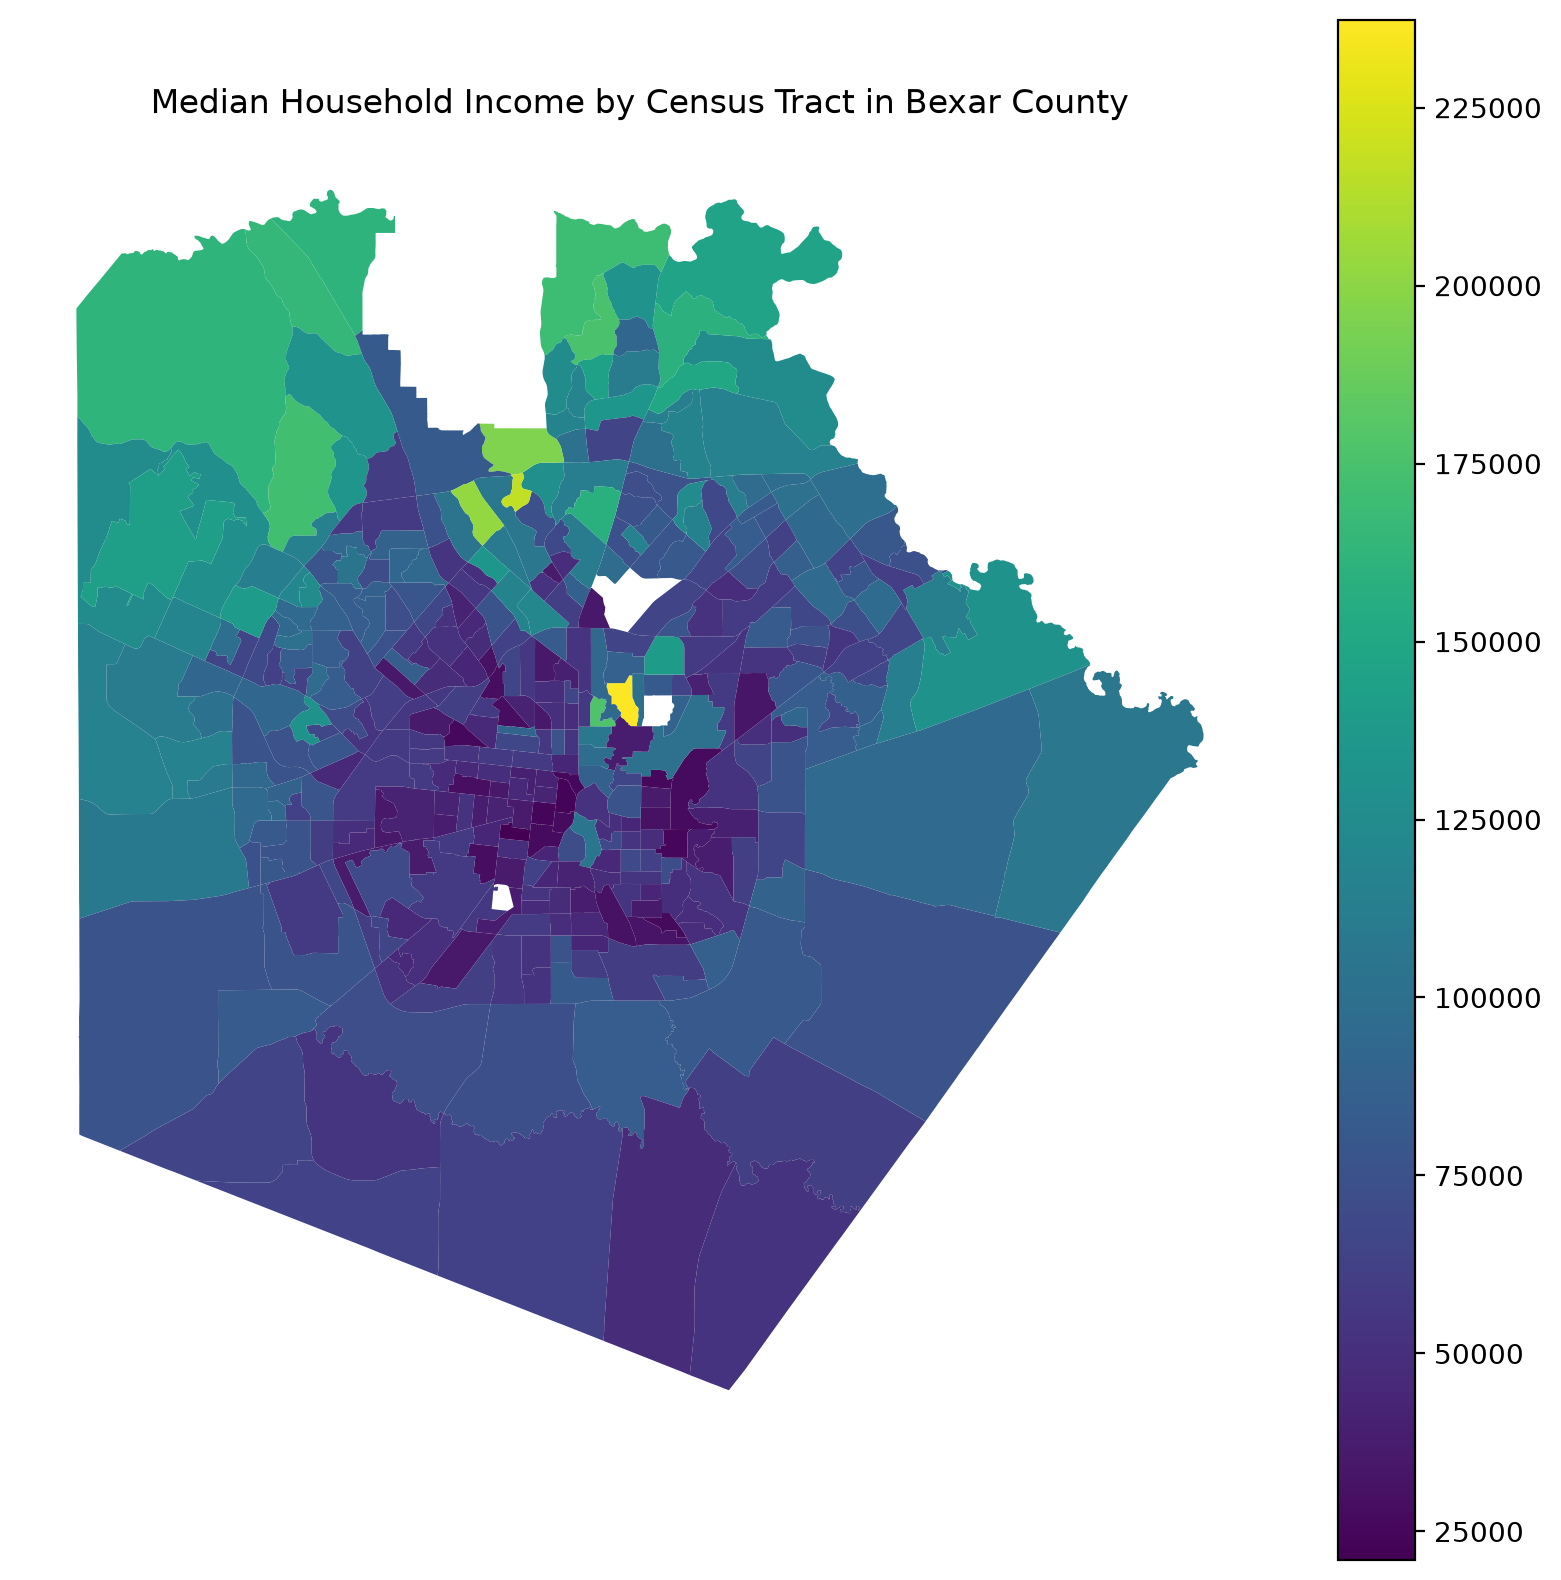

In [38]:
fig, ax = plt.subplots(figsize=(10, 10))

merged.plot(
    column="S1903_C03_001E",
    cmap="viridis",
    legend=True,
    ax=ax
)

plt.title("Median Household Income by Census Tract in Bexar County")
plt.axis("off")
plt.show()

# 2. Mobility Map (No Vehicle Access)

In [39]:
df = pd.read_csv('vehicle_data.csv')

In [40]:
df

,GEO_ID,NAME,S0802_C01_001E,S0802_C01_001M,S0802_C01_002E,S0802_C01_002M,S0802_C01_003E,S0802_C01_003M,S0802_C01_004E,S0802_C01_004M,...,S0802_C05_097E,S0802_C05_097M,S0802_C05_098E,S0802_C05_098M,S0802_C05_099E,S0802_C05_099M,S0802_C05_100E,S0802_C05_100M,S0802_C05_101E,S0802_C05_101M
0,Geography,Geographic Area Name,Estimate!!Total!!Workers 16 years and over,Margin of Error!!Total!!Workers 16 years and over,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,...,Estimate!!Worked from home!!Workers 16 years a...,Margin of Error!!Worked from home!!Workers 16 ...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...
1,1400000US48029110100,Census Tract 1101; Bexar County; Texas,2614,481,9.8,5.8,15.6,6.3,48.5,9.7,...,0,16.6,(X),(X),(X),(X),(X),(X),(X),(X)
2,1400000US48029110300,Census Tract 1103; Bexar County; Texas,1280,476,0.9,1.3,5.3,4.1,34.2,15.2,...,0,22.2,(X),(X),(X),(X),(X),(X),(X),(X)
3,1400000US48029110500,Census Tract 1105; Bexar County; Texas,1048,353,3.4,5.1,7.8,5.3,57.2,11.9,...,61.3,46.4,(X),(X),(X),(X),(X),(X),(X),(X)
4,1400000US48029110600,Census Tract 1106; Bexar County; Texas,1573,339,0,3.1,5.9,6.5,40.5,10.9,...,0,53.1,(X),(X),(X),(X),(X),(X),(X),(X)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,1400000US48029980002,Census Tract 9800.02; Bexar County; Texas,0,15,-,**,-,**,-,**,...,-,**,(X),(X),(X),(X),(X),(X),(X),(X)
372,1400000US48029980003,Census Tract 9800.03; Bexar County; Texas,583,105,9.4,9.7,32.4,22.7,55.1,15.9,...,0,86.7,(X),(X),(X),(X),(X),(X),(X),(X)
373,1400000US48029980004,Census Tract 9800.04; Bexar County; Texas,0,15,-,**,-,**,-,**,...,-,**,(X),(X),(X),(X),(X),(X),(X),(X)
374,1400000US48029980005,Census Tract 9800.05; Bexar County; Texas,25,20,0,73.6,0,73.6,48,44.4,...,0,100,(X),(X),(X),(X),(X),(X),(X),(X)


In [41]:
merged_2 = bexar.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

merged_2["S0802_C01_094E"] = pd.to_numeric(
    merged_2["S0802_C01_094E"],
    errors="coerce"
)

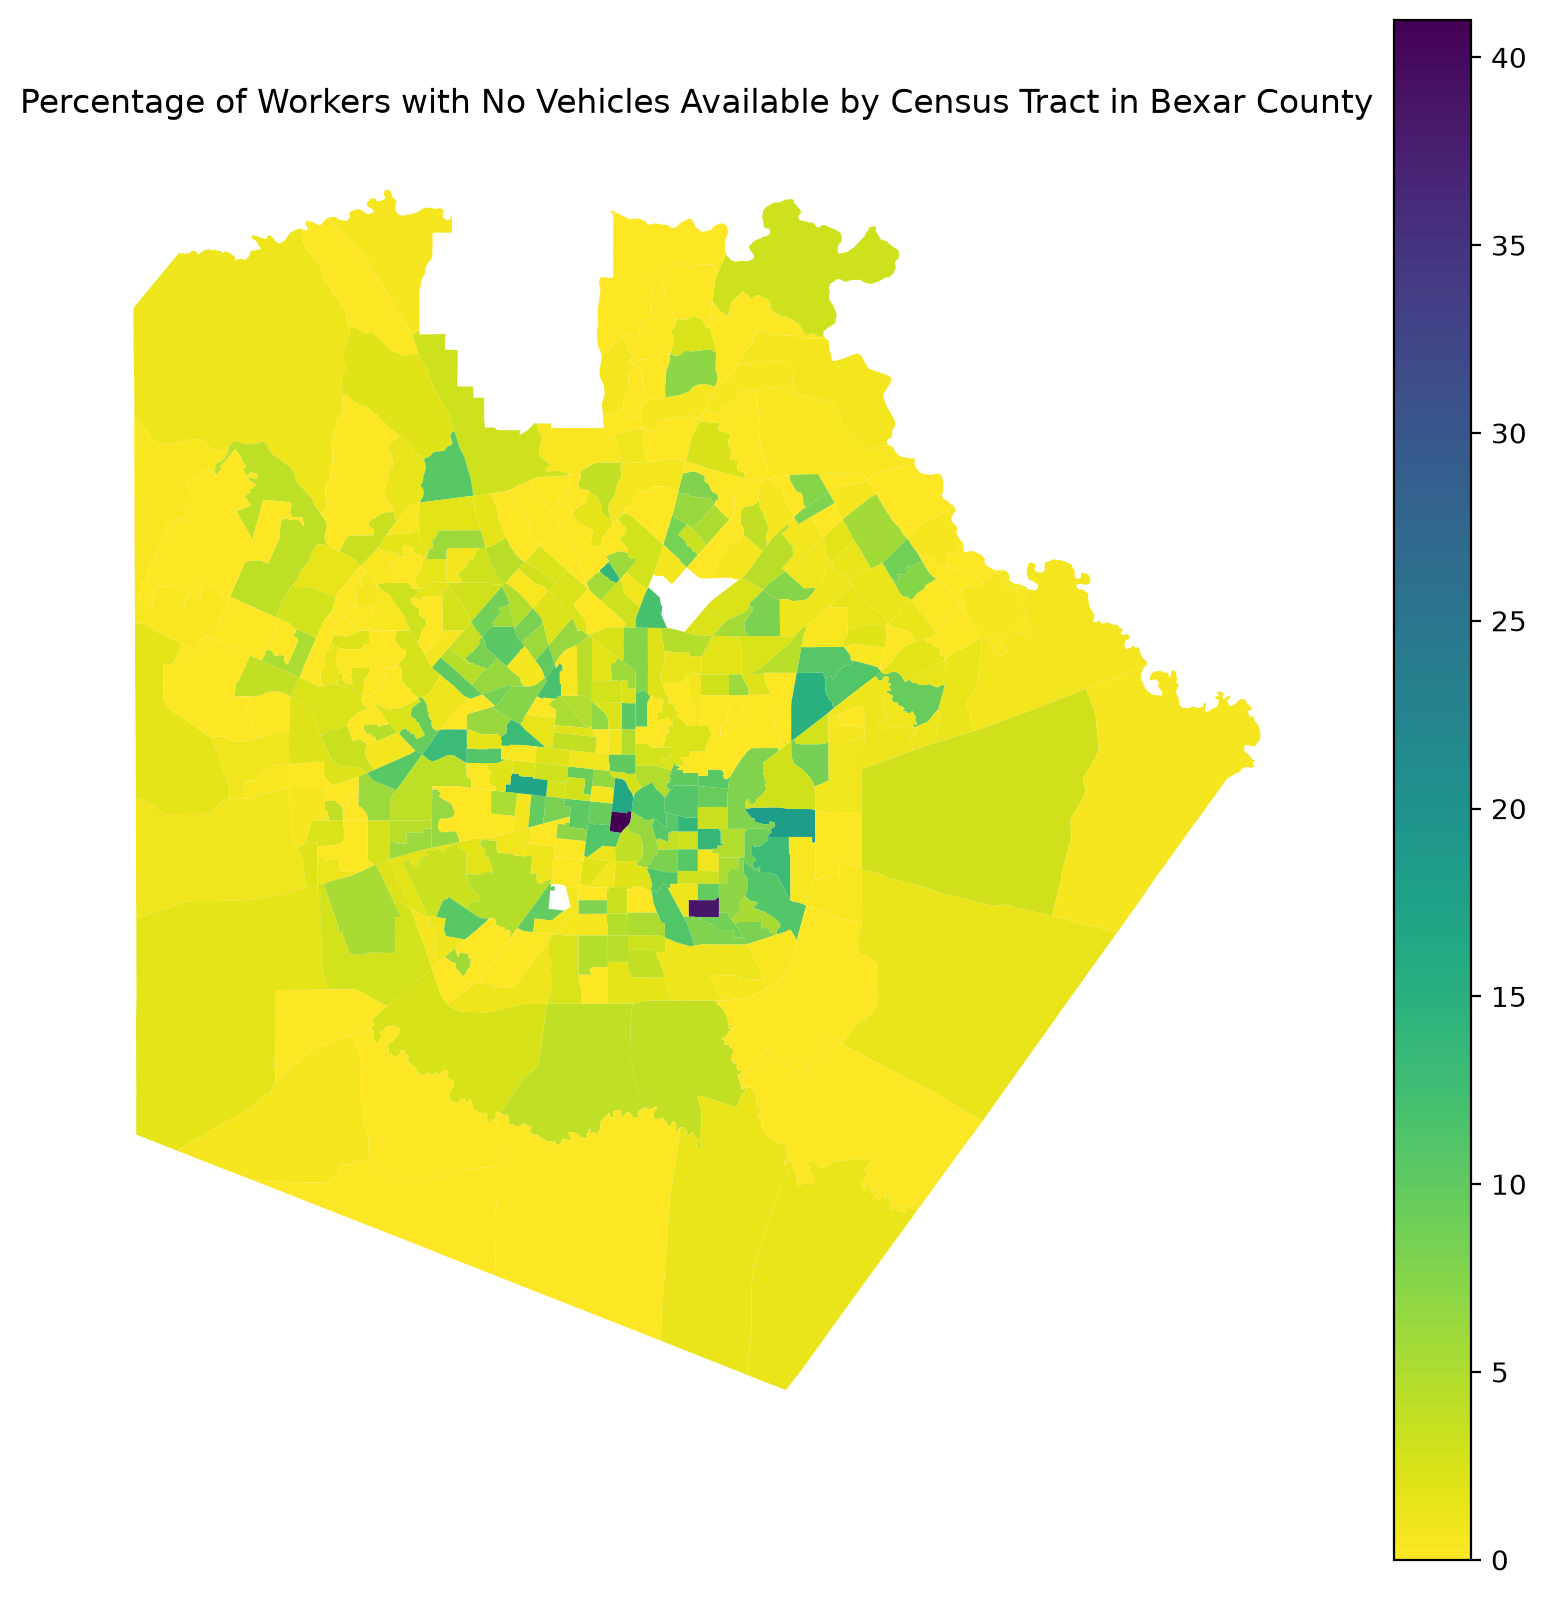

In [42]:
fig, ax = plt.subplots(figsize=(10, 10))

merged_2.plot(
    column="S0802_C01_094E",
    cmap="viridis_r",
    legend=True,
    ax=ax
)

plt.title("Percentage of Workers with No Vehicles Available by Census Tract in Bexar County")
plt.axis("off")
plt.show()

# 3. SNAP Data

In [43]:
df = pd.read_csv('snap_data.csv')
df

,GEO_ID,NAME,S2201_C01_001E,S2201_C01_001M,S2201_C01_002E,S2201_C01_002M,S2201_C01_003E,S2201_C01_003M,S2201_C01_004E,S2201_C01_004M,...,S2201_C06_034E,S2201_C06_034M,S2201_C06_035E,S2201_C06_035M,S2201_C06_036E,S2201_C06_036M,S2201_C06_037E,S2201_C06_037M,S2201_C06_038E,S2201_C06_038M
0,Geography,Geographic Area Name,Estimate!!Total!!Households,Margin of Error!!Total!!Households,Estimate!!Total!!Households!!With one or more ...,Margin of Error!!Total!!Households!!With one o...,Estimate!!Total!!Households!!No people in the ...,Margin of Error!!Total!!Households!!No people ...,Estimate!!Total!!Households!!Married-couple fa...,Margin of Error!!Total!!Households!!Married-co...,...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...
1,1400000US48029110100,Census Tract 1101; Bexar County; Texas,2659,341,694,247,1965,299,396,205,...,(X),(X),(X),(X),8.1,8,19.9,19.7,72,21.3
2,1400000US48029110300,Census Tract 1103; Bexar County; Texas,1139,284,390,122,749,260,215,156,...,(X),(X),(X),(X),3.1,3.8,50.1,21.7,46.8,21.7
3,1400000US48029110500,Census Tract 1105; Bexar County; Texas,1115,136,191,84,924,125,101,39,...,(X),(X),(X),(X),16.4,13.1,37.3,23.3,46.2,23.2
4,1400000US48029110600,Census Tract 1106; Bexar County; Texas,1482,249,659,205,823,205,128,74,...,(X),(X),(X),(X),25.7,28.1,8.8,13.1,65.5,30.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,1400000US48029980002,Census Tract 9800.02; Bexar County; Texas,0,15,0,15,0,15,0,15,...,(X),(X),(X),(X),-,**,-,**,-,**
372,1400000US48029980003,Census Tract 9800.03; Bexar County; Texas,260,52,25,20,235,46,125,37,...,(X),(X),(X),(X),12.4,9.8,38.8,17.2,48.8,17.8
373,1400000US48029980004,Census Tract 9800.04; Bexar County; Texas,0,15,0,15,0,15,0,15,...,(X),(X),(X),(X),-,**,-,**,-,**
374,1400000US48029980005,Census Tract 9800.05; Bexar County; Texas,19,8,8,9,11,11,19,8,...,(X),(X),(X),(X),21.1,39.9,21.1,30.9,57.9,50


In [44]:
merged_3 = bexar.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [45]:
merged_3["S2201_C04_001E"] = pd.to_numeric(
    merged_3["S2201_C04_001E"],
    errors="coerce"
)

In [46]:
#State Median Income
#make sure column is numeric
merged["S1903_C03_001E"] = pd.to_numeric(
    merged["S1903_C03_001E"],
    errors="coerce"
)

#binary variable
merged["binary_income"] = (
    merged["S1903_C03_001E"] < 0.8*78112
).astype(int)
#1 if median income less than 0.8*79721
#0 if median income greater than or equal to 0.8*79721

In [47]:
#State Median Income
#make sure column is numeric
merged["S1903_C03_001E"] = pd.to_numeric(
    merged["S1903_C03_001E"],
    errors="coerce"
)

#binary variable
merged["binary_income"] = (
    merged["S1903_C03_001E"] < 0.8*78112
).astype(int)
#1 if median income less than 0.8*79721
#0 if median income greater than or equal to 0.8*79721

In [48]:
df_2= pd.read_csv('bexar_metropolitan.csv')

In [49]:
gdf = gpd.read_file("tl_2024_48_tract.shp")
harris = gdf[gdf["COUNTYFP"] == "029"]

In [50]:
income = pd.read_csv("income_data.csv")
income.head()

,GEO_ID,NAME,S1903_C01_001E,S1903_C01_001M,S1903_C01_002E,S1903_C01_002M,S1903_C01_003E,S1903_C01_003M,S1903_C01_004E,S1903_C01_004M,...,S1903_C03_036E,S1903_C03_036M,S1903_C03_037E,S1903_C03_037M,S1903_C03_038E,S1903_C03_038M,S1903_C03_039E,S1903_C03_039M,S1903_C03_040E,S1903_C03_040M
0,Geography,Geographic Area Name,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...
1,1400000US48029110100,Census Tract 1101; Bexar County; Texas,2659,341,1515,396,134,153,40,54,...,57276,9439,-,**,40921,20086,37405,15921,-,**
2,1400000US48029110300,Census Tract 1103; Bexar County; Texas,1139,284,569,233,114,106,12,18,...,-,**,117896,91739,-,**,-,**,-,**
3,1400000US48029110500,Census Tract 1105; Bexar County; Texas,1115,136,395,125,116,82,25,42,...,24250,16762,83494,6778,34826,12231,-,**,-,**
4,1400000US48029110600,Census Tract 1106; Bexar County; Texas,1482,249,255,101,101,102,42,43,...,16154,4870,-,**,21448,3831,19678,3195,24012,5966


In [51]:
income["GEOID"] = income["GEO_ID"].str[-11:]

In [52]:
merged_2 = bexar.merge(income, on="GEOID", how="left")

In [53]:
merged_2["S1903_C03_001E"] = pd.to_numeric(
    merged_2["S1903_C03_001E"],
    errors="coerce"
)

merged_2["binary_income_2"] = (
    merged_2["S1903_C03_001E"] < 0.8 * 78112
).astype(int)

In [54]:
[col for col in merged_2.columns if "S1903" in col]

['S1903_C01_001E',
 'S1903_C01_001M',
 'S1903_C01_002E',
 'S1903_C01_002M',
 'S1903_C01_003E',
 'S1903_C01_003M',
 'S1903_C01_004E',
 'S1903_C01_004M',
 'S1903_C01_005E',
 'S1903_C01_005M',
 'S1903_C01_006E',
 'S1903_C01_006M',
 'S1903_C01_007E',
 'S1903_C01_007M',
 'S1903_C01_008E',
 'S1903_C01_008M',
 'S1903_C01_009E',
 'S1903_C01_009M',
 'S1903_C01_010E',
 'S1903_C01_010M',
 'S1903_C01_011E',
 'S1903_C01_011M',
 'S1903_C01_012E',
 'S1903_C01_012M',
 'S1903_C01_013E',
 'S1903_C01_013M',
 'S1903_C01_014E',
 'S1903_C01_014M',
 'S1903_C01_015E',
 'S1903_C01_015M',
 'S1903_C01_016E',
 'S1903_C01_016M',
 'S1903_C01_017E',
 'S1903_C01_017M',
 'S1903_C01_018E',
 'S1903_C01_018M',
 'S1903_C01_019E',
 'S1903_C01_019M',
 'S1903_C01_020E',
 'S1903_C01_020M',
 'S1903_C01_021E',
 'S1903_C01_021M',
 'S1903_C01_022E',
 'S1903_C01_022M',
 'S1903_C01_023E',
 'S1903_C01_023M',
 'S1903_C01_024E',
 'S1903_C01_024M',
 'S1903_C01_025E',
 'S1903_C01_025M',
 'S1903_C01_026E',
 'S1903_C01_026M',
 'S1903_C01_

In [55]:
df_poverty = pd.read_csv('bexar_poverty.csv')
df_poverty

,GEO_ID,NAME,S1903_C01_001E,S1903_C01_001M,S1903_C01_002E,S1903_C01_002M,S1903_C01_003E,S1903_C01_003M,S1903_C01_004E,S1903_C01_004M,...,S1903_C03_036E,S1903_C03_036M,S1903_C03_037E,S1903_C03_037M,S1903_C03_038E,S1903_C03_038M,S1903_C03_039E,S1903_C03_039M,S1903_C03_040E,S1903_C03_040M
0,Geography,Geographic Area Name,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...
1,310M700US41700,"San Antonio-New Braunfels, TX Metro Area",1006232,7517,518514,9444,73913,4415,14121,2816,...,37299,2999,69571,6539,52943,4063,47466,4047,80775,7584


In [57]:
#low-income tracts
df_poverty = pd.read_csv('bexar_poverty.csv')
df_poverty

,GEO_ID,NAME,S1903_C01_001E,S1903_C01_001M,S1903_C01_002E,S1903_C01_002M,S1903_C01_003E,S1903_C01_003M,S1903_C01_004E,S1903_C01_004M,...,S1903_C03_036E,S1903_C03_036M,S1903_C03_037E,S1903_C03_037M,S1903_C03_038E,S1903_C03_038M,S1903_C03_039E,S1903_C03_039M,S1903_C03_040E,S1903_C03_040M
0,Geography,Geographic Area Name,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...
1,310M700US41700,"San Antonio-New Braunfels, TX Metro Area",1006232,7517,518514,9444,73913,4415,14121,2816,...,37299,2999,69571,6539,52943,4063,47466,4047,80775,7584


In [61]:
#merging SHP file
merged_3 = bexar.merge(
    df_poverty,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [62]:
#merging SHP file
merged_3 = bexar.merge(
    df_poverty,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [67]:
[c for c in merged_3.columns if "S1701" in c][:20]

[]

In [69]:
poverty = pd.read_csv("bexar_poverty.csv", skiprows=[1])
poverty["GEOID"] = poverty["GEO_ID"].str[-11:]

tracts = gpd.read_file("tl_2024_48_tract.shp")
dallas_tracts = tracts[tracts["COUNTYFP"] == "029"].copy()

merged_3 = dallas_tracts.merge(poverty, on="GEOID", how="left")

[c for c in merged_3.columns if "S1701_C03_001E" in c]

C:\Users\saraz\AppData\Local\Temp\ipykernel_22060\3169752121.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  poverty["GEOID"] = poverty["GEO_ID"].str[-11:]


[]

In [70]:
poverty.head()

,GEO_ID,NAME,S1903_C01_001E,S1903_C01_001M,S1903_C01_002E,S1903_C01_002M,S1903_C01_003E,S1903_C01_003M,S1903_C01_004E,S1903_C01_004M,...,S1903_C03_036M,S1903_C03_037E,S1903_C03_037M,S1903_C03_038E,S1903_C03_038M,S1903_C03_039E,S1903_C03_039M,S1903_C03_040E,S1903_C03_040M,GEOID
0,310M700US41700,"San Antonio-New Braunfels, TX Metro Area",1006232,7517,518514,9444,73913,4415,14121,2816,...,2999,69571,6539,52943,4063,47466,4047,80775,7584,M700US41700


In [71]:
poverty = pd.read_csv("bexar_poverty.csv", skiprows=[1])

In [72]:
[c for c in poverty.columns if "S1701_C03" in c][:20]

[]

In [73]:
poverty = pd.read_csv("ACSST5Y2024.S1701-Data.csv", skiprows=[1])

[c for c in poverty.columns if "S1701" in c][:20]

['S1701_C01_001E',
 'S1701_C01_001M',
 'S1701_C01_002E',
 'S1701_C01_002M',
 'S1701_C01_003E',
 'S1701_C01_003M',
 'S1701_C01_004E',
 'S1701_C01_004M',
 'S1701_C01_005E',
 'S1701_C01_005M',
 'S1701_C01_006E',
 'S1701_C01_006M',
 'S1701_C01_007E',
 'S1701_C01_007M',
 'S1701_C01_008E',
 'S1701_C01_008M',
 'S1701_C01_009E',
 'S1701_C01_009M',
 'S1701_C01_010E',
 'S1701_C01_010M']

In [74]:
poverty["GEOID"] = poverty["GEO_ID"].str[-11:]

merged_3 = dallas_tracts.merge(poverty, on="GEOID", how="left")

C:\Users\saraz\AppData\Local\Temp\ipykernel_22060\2049736417.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  poverty["GEOID"] = poverty["GEO_ID"].str[-11:]


In [75]:
merged_3["S1701_C03_001E"] = pd.to_numeric(
    merged_3["S1701_C03_001E"],
    errors="coerce"
)

In [76]:
#make sure values numeric
merged_3["S1701_C03_001E"] = pd.to_numeric(
    merged_3["S1701_C03_001E"],
    errors="coerce"
)

In [77]:
merged_3["binary_poverty"] = (
    merged_3["S1701_C03_001E"] >= 20.0
).astype(int)

c:\Users\saraz\anaconda3\envs\pandas\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


In [79]:
# merging all datasets 
#make copy of binary columns in first dataframe 
combined = merged.copy()

combined["binary_income_2"] = merged_2["binary_income_2"].values
combined["binary_poverty"] = merged_3["binary_poverty"].values

#final USDA criterion
combined["binary_low_income"] = (
    (combined["binary_income"] == 1) |
    (combined["binary_income_2"] == 1) |
    (combined["binary_poverty"] == 1)
).astype(int)

#plot
combined.plot(
    column="binary_low_income",
    cmap=cmap,
    categorical=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

<Axes: title={'center': 'Percentage of Workers with No Vehicles Available by Census Tract in Bexar County'}>

In [80]:
#each condition as an or statement 
combined["binary_low_income"] = (
    (combined["binary_income"] == 1) |
    (combined["binary_income_2"] == 1) |
    (combined["binary_poverty"] == 1)
).astype(int)

In [81]:
combined.plot(
    column="binary_low_income",
    cmap=cmap,
    categorical=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

<Axes: title={'center': 'Percentage of Workers with No Vehicles Available by Census Tract in Bexar County'}>

In [86]:
# importing snap data 
# filter by state and county (Bexar County, TX)

df = pd.read_csv("snap_retailer_location_data.csv")
bexar_snap = df[(df["State"]== "TX") & (df["County"]=="BEXAR")]

print(bexar_snap.shape)
print(bexar_snap["Store_Type"].value_counts())

(1304, 17)
Store_Type
Convenience Store      758
Other                  295
Supermarket             85
Grocery Store           79
Super Store             62
Specialty Store         18
Farmers and Markets      7
Name: count, dtype: int64


In [87]:
# want to exclude Dollar General, Dollar Tree, CVS Pharmacy, CVS, Family Dollar,  Walgreens

excluded_others=["Dollar", "CVS", "Walgreen", "Walgrens", "Pharmacy"]

new_bexar_data = bexar_snap[(bexar_snap["Store_Type"] == "Other") 
    & ~bexar_snap["Store_Name"].str.contains("|".join(excluded_others), case=False, na=False)].copy()
print(new_bexar_data.shape)
print(new_bexar_data["Store_Name"].unique())

(21, 17)
<StringArray>
[        'Mama B International Marketplace',
                            'M & I Grocery',
                 'CHICHO BOYS FRUIT MARKET',
      'HUNG PHONG ORIENTAL SUPERMARKET INC',
                   'NORTHSIDE ORIENTAL MKT',
                             'THRIF T MART',
  'La Michoacana Meat Market San Antonio 2',
                          'Himalayan Bazar',
                       'La Frontera Molino',
 'Tortilleria Taqueria Y Gorditas La Milpa',
           'La Michoacana Meat Market Sa16',
           'La Michoacana Meat Market SA11',
           'La Michoacana Meat Market SA14',
                   'El Torito Meat Market ',
                     'Eagle African Market',
        'Asseye African & Caribbean Market',
                      'El Folklor Bakery 2',
                     'Ashiana Super Market',
                       'Arlan's Market #16',
                'La Carniceria Meat Market',
                         'Mario's Bakery 2']
Length: 21, dtype: str


In [88]:
kept_bexar_others=["CHICHO BOYS FRUIT MARKET", "HUNG PHONG ORIENTAL SUPERMARKET INC", "NORTHSIDE ORIENTAL MKT", "THRIF T MART", "La Michoacana Meat Market",
                 "Himalayan Bazar", "Asseye African & Caribbean Market","Ashiana Super Market", "Arlan's Market", "Braum"]

In [89]:
excluded_bexar_others=["Mama B International Marketplace", "M & I Grocery", "La Frontera Molino", "Tortilleria Taqueria Y Gorditas La Milpa", "El Torito Meat Market",
                     "Eagle African Market", "El Folklor Bakery", "La Carniceria Meat Market", "Mario's Bakery"]

In [90]:
# filter out stores that are not grocery stores
included = ["Super Store","Supermarket","Grocery Store", "Farmers and Markets"]

keywords_pattern = "|".join(kept_bexar_others)

cleaned_snap_data = bexar_snap[
    bexar_snap["Store_Type"].isin(included) |
    bexar_snap["Store_Name"].str.contains(keywords_pattern, case=False, na=False)
].copy()

print(cleaned_snap_data.shape)
print(cleaned_snap_data["Store_Name"].unique())

(245, 17)
<StringArray>
[            'Asia Supermarket Group',              'Sisters African Store',
                            'HEB 262',                            'HEB 385',
                            'HEB 556',             'CULEBRA MEAT MARKET 01',
                       'Walmart 3279',                 'Target Store T1785',
        'LACKLAND AFB COMMISSARY 622',                      'Target T 1523',
 ...
                 'Taqwa Halal Market',    'Kabul International Food Market',
               'Canyon Golf Market 1', 'Soil Sisters Farmers Market NAFMNP',
                 'N & N Asian Market',       'Sashas International  Market',
    'Al Madina Meat Market And Grill',                 'HEB Food Store 807',
                           'El Bocca',              'San Antonio Food Bank']
Length: 244, dtype: str


In [91]:
# remove columns that are not needed :"Additonal_Address", "Incentive_Program", "Grantee_Name", "X", "Y"

final_cleaned_snap_data = cleaned_snap_data.drop(columns=["Additonal_Address", "Incentive_Program", "Grantee_Name", "X", "Y", "Zip4"])

In [92]:
# Check for duplicate store names at the same address
dupes = final_cleaned_snap_data[cleaned_snap_data.duplicated(subset=["Store_Name", "Store_Street_Address"], keep=False)]
print(dupes[["Store_Name", "Store_Street_Address"]])

Empty DataFrame
Columns: [Store_Name, Store_Street_Address]
Index: []


In [93]:
final_cleaned_snap_data.to_csv("cleaned_bexar_snap_data.csv", index=False)
print(final_cleaned_snap_data.shape)
print(final_cleaned_snap_data[["Store_Name", "Latitude", "Longitude", "Store_Type"]].head())

(245, 11)
                  Store_Name   Latitude  Longitude     Store_Type
1213  Asia Supermarket Group  29.511795 -98.392914    Super Store
2148   Sisters African Store  29.509039 -98.410248  Grocery Store
4173                 HEB 262  29.480915 -98.595490    Supermarket
4939                 HEB 385  29.470903 -98.495605    Supermarket
5422                 HEB 556  29.464632 -98.526077    Supermarket


In [97]:
%matplotlib inline

# read CSV
df = pd.read_csv("cleaned_snap_bexar_data.csv")

# make sure longitude/latitude are numeric
df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")
df["Latitude"] = pd.to_numeric(df["Latitude"], errors="coerce")

# remove rows with missing coordinates
df = df.dropna(subset=["Longitude", "Latitude"])

# create GeoDataFrame
geo_df = gpd.GeoDataFrame(
    df[[
        "Store_Name",
        "Store_Street_Address",
        "City",
        "Zip_Code",
        "Store_Type",
        "Latitude",
        "Longitude"
    ]],
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
    crs="EPSG:4326"
)

geo_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'cleaned_snap_bexar_data.csv'